In [5]:
import pandas as pd
import openai
from dotenv import load_dotenv
load_dotenv()
import json
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [35]:
client = openai.OpenAI()
def openai_ask(question, answer, model="gpt-4o"):
    return client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": """
            You are an essay grader assistant for technical coding in a technical interview, give the rating based on technical accuracy and communication efficiency. In here, you are required\n    to grade the answer following a specific schema, with a score from 0 to 100. The schema is: \n    {\"score\": <real-type, 0.0-100.0, grades should not be afraid to use floats and numbers NOT divisible by 5 for the sake of granularity.>}\n    \n    Do not add remarks. The interviewer has asked the following question:
            """ + " " + question},
            {"role": "user", "content": answer},
        
        ], temperature=0.1
    ).choices[0].message.content

In [36]:
openai_ask("A dashboard API takes 50 seconds to return. The DB team says the sales table is too large. How would you improve this?", """
First, I’d want to confirm where the bottleneck is. Since the DB team suspects the sales table is the issue, I’d start by profiling the specific query — looking at execution time, query plan, and whether full table scans or unindexed columns are involved.

If the query uses aggregates like SUM() or AVG() on a large dataset, one low-lift optimization might be adding proper indexes, especially on any WHERE, JOIN, or GROUP BY columns. But if it’s already optimized and still slow due to sheer data size, I’d explore data pre-aggregation — maybe creating a summary table that rolls up metrics by day or by region, updated periodically via a scheduled ETL job.

If the dashboard always shows the same data unless explicitly refreshed, caching is also a good option — either at the query level (e.g., Redis) or on the frontend via stale-while-revalidate.

Finally, if this dashboard serves many users, I’d assess whether we can paginate or lazy load certain sections, especially if only part of the data is visible at a time.

So overall: profile the query, check indexes, consider pre-aggregated summaries, and cache or paginate where possible.
""")

'{"score": 92.5}'

In [3]:
df_quiz_02_responses = pd.read_excel('CSIT221-JVS-Quiz 02 - Up Until Structures-responses.xlsx')
df_quiz_02_grades = pd.read_excel('CSIT221-JVS-Quiz 02 - Up Until Structures-grades.xlsx')
df_quiz_02_responses.head()

,Surname,First name,Email address,State,Started on,Completed,Time taken,Grade/15.00,Question 1,Response 1,...,Question 3,Response 3,Question 4,Response 4,Question 5,Response 5,Question 6,Response 6,Question 7,Response 7
0,MARANGA,XAVIER DAVID,xavierdavid.maranga@cit.edu,Finished,10 September 2021 10:00 AM,10 September 2021 10:15 AM,15 mins 1 sec,14.0,To make a method abstract (i.e. let its childr...,True,...,If I want to declare REMOVE(int _pos_) as abst...,False,Using this code:\n\nswitch (x):\n case 0:\n ...,x=0; y=-3\n -> 1; x=4; y=13\n -> 2; x=13; y=0\...,"Given the image above, how many shifts or move...",6,"When do we use class instead of struct? Also, ...",We use class if we need to have public or priv...,Why does C++ use pointers even if Java and oth...,Because C++ is a low-level programming languag...
1,Barcenilla,Adrian Jay,adrianjay.barcenilla@cit.edu,Finished,10 September 2021 10:00 AM,10 September 2021 10:14 AM,13 mins 40 secs,11.5,To make a method abstract (i.e. let its childr...,True,...,If I want to declare REMOVE(int _pos_) as abst...,True,Using this code:\n\nswitch (x):\n case 0:\n ...,x=0; y=0\n -> 0; x=4; y=13\n -> 2; x=13; y=0\n...,"Given the image above, how many shifts or move...",5,"When do we use class instead of struct? Also, ...","In an overview, structs and classes are basica...",Why does C++ use pointers even if Java and oth...,Pointers help C++ to improve the processing ti...
2,GEAGONIA,MARK YURI,mygeagonia@gmail.com,Finished,10 September 2021 10:00 AM,10 September 2021 10:15 AM,15 mins 2 secs,11.5,To make a method abstract (i.e. let its childr...,True,...,If I want to declare REMOVE(int _pos_) as abst...,True,Using this code:\n\nswitch (x):\n case 0:\n ...,x=0; y=0\n -> 0; x=0; y=-3\n -> 1; x=4; y=13\n...,"Given the image above, how many shifts or move...",5,"When do we use class instead of struct? Also, ...","Based on my understanding, using class provide...",Why does C++ use pointers even if Java and oth...,C++ use pointers so that data can be manipulat...
3,MIONES,JOHN WILLIAM,johnwilliam.miones@cit.edu,Finished,10 September 2021 10:00 AM,10 September 2021 10:16 AM,15 mins 13 secs,2.5,To make a method abstract (i.e. let its childr...,False,...,If I want to declare REMOVE(int _pos_) as abst...,True,Using this code:\n\nswitch (x):\n case 0:\n ...,x=4; y=13\n -> 0; x=0; y=-3\n -> 2; x=13; y=0\...,"Given the image above, how many shifts or move...",5,"When do we use class instead of struct? Also, ...",-,Why does C++ use pointers even if Java and oth...,"As far as I know, we use pointers to easily ac..."
4,DAMALERIO,JOHN BENEDICT,johnbenedictdamalers@yahoo.com,Finished,10 September 2021 10:00 AM,10 September 2021 10:15 AM,14 mins 38 secs,12.5,To make a method abstract (i.e. let its childr...,True,...,If I want to declare REMOVE(int _pos_) as abst...,False,Using this code:\n\nswitch (x):\n case 0:\n ...,x=0; y=-3\n -> 1; x=4; y=13\n -> 2; x=0; y=0\n...,"Given the image above, how many shifts or move...",6,"When do we use class instead of struct? Also, ...",Generally both class and struct have no big di...,Why does C++ use pointers even if Java and oth...,"C++ has pointers because, it is an important t..."


In [4]:
df_quiz_02_responses['ID'] = df_quiz_02_responses['First name'] + df_quiz_02_responses['Surname']

In [5]:
df_quiz_02_essays = df_quiz_02_responses[['ID', 'Question 6', 'Response 6', 'Question 7', 'Response 7']];
df_quiz_02_essays.head()

,ID,Question 6,Response 6,Question 7,Response 7
0,XAVIER DAVIDMARANGA,"When do we use class instead of struct? Also, ...",We use class if we need to have public or priv...,Why does C++ use pointers even if Java and oth...,Because C++ is a low-level programming languag...
1,Adrian JayBarcenilla,"When do we use class instead of struct? Also, ...","In an overview, structs and classes are basica...",Why does C++ use pointers even if Java and oth...,Pointers help C++ to improve the processing ti...
2,MARK YURIGEAGONIA,"When do we use class instead of struct? Also, ...","Based on my understanding, using class provide...",Why does C++ use pointers even if Java and oth...,C++ use pointers so that data can be manipulat...
3,JOHN WILLIAMMIONES,"When do we use class instead of struct? Also, ...",-,Why does C++ use pointers even if Java and oth...,"As far as I know, we use pointers to easily ac..."
4,JOHN BENEDICTDAMALERIO,"When do we use class instead of struct? Also, ...",Generally both class and struct have no big di...,Why does C++ use pointers even if Java and oth...,"C++ has pointers because, it is an important t..."


In [6]:
question_7 = df_quiz_02_essays['Question 7'][0]
results_7_quiz_02 = []
results_default_model = []


for item in df_quiz_02_essays['Response 7']:
    print(f"LOADING item#{len(results_7_quiz_02) + 1}")
    try:
        result = openai_ask(question_7, item)
        result_2 = openai_ask(question_7, item, model='gpt-4o-mini')
        result_f = json.loads(result)['score']
        result_f2 = json.loads(result_2)['score']
    except:
        results_7_quiz_02.append(np.nan)
        results_default_model.append(np.nan)
        continue
    results_7_quiz_02.append(result_f)
    results_default_model.append(result_f2)
    
    

LOADING item#1
LOADING item#2
LOADING item#3
LOADING item#4
LOADING item#5
LOADING item#6
LOADING item#7
LOADING item#8
LOADING item#9
LOADING item#10
LOADING item#11
LOADING item#12
LOADING item#13
LOADING item#14
LOADING item#15
LOADING item#16
LOADING item#17
LOADING item#18
LOADING item#19
LOADING item#20
LOADING item#21
LOADING item#22
LOADING item#23
LOADING item#24
LOADING item#25
LOADING item#26
LOADING item#27
LOADING item#28
LOADING item#29
LOADING item#30
LOADING item#31
LOADING item#32
LOADING item#33
LOADING item#34
LOADING item#35
LOADING item#36
LOADING item#37
LOADING item#38
LOADING item#39
LOADING item#40
LOADING item#41
LOADING item#42
LOADING item#43
LOADING item#44
LOADING item#45
LOADING item#46
LOADING item#47
LOADING item#48
LOADING item#49
LOADING item#50
LOADING item#51
LOADING item#52
LOADING item#53
LOADING item#54
LOADING item#55
LOADING item#56
LOADING item#57
LOADING item#58
LOADING item#59
LOADING item#60
LOADING item#61
LOADING item#62
LOADING item#63
L

In [7]:
question_7_review = pd.DataFrame({
    'ID' : df_quiz_02_essays['ID'],
    'Results' : results_7_quiz_02,
    'Results-Non-Tuned': results_default_model
})
question_7_review.head()

,ID,Results,Results-Non-Tuned
0,XAVIER DAVIDMARANGA,116.67,70.0
1,Adrian JayBarcenilla,133.33,75.0
2,MARK YURIGEAGONIA,133.33,55.0
3,JOHN WILLIAMMIONES,116.67,30.0
4,JOHN BENEDICTDAMALERIO,83.33,25.0


In [8]:
df_quiz_02_grades['ID'] = df_quiz_02_grades['First name'] + df_quiz_02_grades['Surname']
joined = pd.merge(df_quiz_02_grades[['ID', 'Q. 7 /4.00']], question_7_review, on='ID')

In [9]:
joined.rename(columns={'Q. 7 /4.00': 'Actual Grade'}, inplace=True)
joined.head()

,ID,Actual Grade,Results,Results-Non-Tuned
0,XAVIER DAVIDMARANGA,4.00,116.67,70.0
1,Adrian JayBarcenilla,4.00,133.33,75.0
2,MARK YURIGEAGONIA,3.50,133.33,55.0
3,JOHN WILLIAMMIONES,2.00,116.67,30.0
4,JOHN BENEDICTDAMALERIO,3.50,83.33,25.0


In [10]:
def transform_behavior(x):
    try:
        return float(x) * 25
    except:
        return np.nan
    

def meta_transform(x):
    
    def transform_behavior_inner(y):
        try:
            return float(y) * (100/x)
        except:
            return np.nan
    
    return transform_behavior_inner

In [11]:
joined['Actual Grade'] = joined['Actual Grade'].apply(transform_behavior)

In [12]:
joined = joined.dropna()
joined.head()

,ID,Actual Grade,Results,Results-Non-Tuned
0,XAVIER DAVIDMARANGA,100.0,116.67,70.0
1,Adrian JayBarcenilla,100.0,133.33,75.0
2,MARK YURIGEAGONIA,87.5,133.33,55.0
3,JOHN WILLIAMMIONES,50.0,116.67,30.0
4,JOHN BENEDICTDAMALERIO,87.5,83.33,25.0


In [13]:

mean_squared_error(joined['Actual Grade'], joined['Results']), mean_squared_error(joined['Actual Grade'], joined['Results-Non-Tuned'])

(np.float64(2041.4602849999999), np.float64(974.5775))

In [14]:
def read_jsonl(file_path):
    """
    Reads a JSONL file and returns a list of JSON objects.
    
    :param file_path: Path to the JSONL file.
    :return: List of dictionaries representing JSON objects.
    """
    data = []
    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            data.append(json.loads(line))
    return data

def write_jsonl(file_path, *data_lists):
    """
    Writes multiple lists of JSON objects to a JSONL file, appending them.
    
    :param file_path: Path to the JSONL file.
    :param data_lists: One or more lists of dictionaries to write.
    """
    with open(file_path, "w", encoding="utf-8") as file:
        for data_list in data_lists:
            print("Running")
            print(data_list)
            for record in data_list:
                file.write(json.dumps({"messages": record}, ensure_ascii=False) + "\n")

In [15]:
def transform_jsonl_compat(question, answer, grade):
    return [
                {"role": "system", "content": """You are an essay grader assistant for technical coding in a technical interview. In here, you are required to grade the answer following a specific schema, with a score from 0 to 100. The schema is:  {\"score\": <real-type, 0.0-100.0, grades should not be afraid to use floats and numbers not divisible by 5 for the sake of granularity.>} Do not add remarks. The interviewer has asked the following question:
            """ + " " + question},
                 {"role": "user", "content": answer},
                {"role": "assistant", "content": """ {"score": """ + str(grade) + """} """},
            ]

In [16]:
df_quiz_02_essays.head()

,ID,Question 6,Response 6,Question 7,Response 7
0,XAVIER DAVIDMARANGA,"When do we use class instead of struct? Also, ...",We use class if we need to have public or priv...,Why does C++ use pointers even if Java and oth...,Because C++ is a low-level programming languag...
1,Adrian JayBarcenilla,"When do we use class instead of struct? Also, ...","In an overview, structs and classes are basica...",Why does C++ use pointers even if Java and oth...,Pointers help C++ to improve the processing ti...
2,MARK YURIGEAGONIA,"When do we use class instead of struct? Also, ...","Based on my understanding, using class provide...",Why does C++ use pointers even if Java and oth...,C++ use pointers so that data can be manipulat...
3,JOHN WILLIAMMIONES,"When do we use class instead of struct? Also, ...",-,Why does C++ use pointers even if Java and oth...,"As far as I know, we use pointers to easily ac..."
4,JOHN BENEDICTDAMALERIO,"When do we use class instead of struct? Also, ...",Generally both class and struct have no big di...,Why does C++ use pointers even if Java and oth...,"C++ has pointers because, it is an important t..."


In [17]:
write_jsonl('sample.jsonl', [transform_jsonl_compat(question_7, df_quiz_02_essays['Response 7'][0], 100)], )

Running
[[{'role': 'system', 'content': 'You are an essay grader assistant for technical coding in a technical interview. In here, you are required to grade the answer following a specific schema, with a score from 0 to 100. The schema is:  {"score": <real-type, 0.0-100.0, grades should not be afraid to use floats and numbers not divisible by 5 for the sake of granularity.>} Do not add remarks. The interviewer has asked the following question:\n             Why does C++ use pointers even if Java and other high-level programming languages don\'t use them? Why do we use them?'}, {'role': 'user', 'content': "Because C++ is a low-level programming language wherein it doesn't care so much about security while Java and other high-level programming languages care about security. We also use pointers in C++ so that we can pass by reference instead of passing by value in functions."}, {'role': 'assistant', 'content': ' {"score": 100} '}]]


In [18]:
input_shapes = df_quiz_02_essays

In [19]:
question_6 = df_quiz_02_essays['Question 6'][0]
joined_training_set = pd.merge(df_quiz_02_essays, df_quiz_02_grades, on='ID')
joined_training_set.rename(columns={
    'Q. 6 /5.00': 'Q6-Grade',
    'Q. 7 /4.00': 'Q7-Grade'
}, inplace=True)
joined_training_set['Q6-Grade'] = joined_training_set['Q6-Grade'].apply(meta_transform(5))
joined_training_set['Q7-Grade'] = joined_training_set['Q7-Grade'].apply(meta_transform(4))
joined_training_set.dropna(inplace=True)
train_q6 = joined_training_set[['Response 6', 'Q6-Grade']]
train_q7 = joined_training_set[['Response 7', 'Q7-Grade']]

In [20]:
train_q6

,Response 6,Q6-Grade
0,We use class if we need to have public or priv...,80.0
1,"In an overview, structs and classes are basica...",90.0
2,"Based on my understanding, using class provide...",80.0
4,Generally both class and struct have no big di...,80.0
5,Use struct for plain-old-data structures that ...,80.0
...,...,...
97,We need to use class if we want to have a feat...,90.0
98,We use class instead of struct when we want it...,100.0
99,We use class for complex data structures like ...,60.0
101,Class are private by default. This enables not...,40.0


In [21]:
q6_jsonl_compat = [] 
for item in train_q6.iterrows():
    out= transform_jsonl_compat(question_6, item[1]['Response 6'], item[1]['Q6-Grade'])
    q6_jsonl_compat.append(out)

In [22]:
q7_jsonl_compat = []
for item in train_q7.iterrows():
    out= transform_jsonl_compat(question_7, item[1]['Response 7'], item[1]['Q7-Grade'])
    q7_jsonl_compat.append(out)

In [23]:
prev = read_jsonl('output-2.jsonl')


In [24]:
final_responses_df = pd.read_excel('CSIT221-JVS-Final Examinations - Written-responses.xlsx')
final_grades_df = pd.read_excel('CSIT221-JVS-Final Examinations - Written-grades.xlsx')
final_responses_df['ID'] = final_responses_df['First name'] + final_responses_df['Surname']
final_grades_df['ID'] = final_grades_df['First name'] + final_grades_df['Surname']
merged_finals = pd.merge(final_responses_df, final_grades_df, on='ID')
merged_finals.head()

,Surname_x,First name_x,Email address_x,State_x,Started on_x,Completed_x,Time taken_x,Grade/51.00_x,Question 1,Response 1,...,Q. 26 /1.00,Q. 27 /1.00,Q. 28 /1.00,Q. 29 /1.00,Q. 30 /1.00,Q. 31 /1.00,Q. 32 /4.00,Q. 33 /3.00,Q. 34 /3.00,Q. 35 /3.00
0,Barcenilla,Adrian Jay,adrianjay.barcenilla@cit.edu,Finished,20 October 2021 8:34 AM,20 October 2021 8:59 AM,24 mins 40 secs,43.5,How many node pointers does a node in a Binary...,3,...,1.0,0.0,1.0,1.0,0.0,1.0,4.00,3.00,1.50,3.0
1,GUEVARRA,JUSTIN BLAISE,justinguevarra45@yahoo.com,Finished,20 October 2021 8:34 AM,20 October 2021 8:56 AM,22 mins 3 secs,35.0,How many node pointers does a node in a Binary...,2,...,1.0,0.0,1.0,1.0,1.0,0.0,2.00,2.00,3.00,1.0
2,MIONES,JOHN WILLIAM,johnwilliam.miones@cit.edu,Finished,20 October 2021 8:34 AM,20 October 2021 9:14 AM,40 mins 34 secs,43.0,How many node pointers does a node in a Binary...,3,...,1.0,0.0,1.0,0.0,1.0,1.0,3.00,3.00,3.00,3.0
3,BACALSO,SLY KINT,slykint.bacalso@cit.edu,Finished,20 October 2021 8:34 AM,20 October 2021 9:04 AM,30 mins 2 secs,34.5,How many node pointers does a node in a Binary...,2,...,1.0,0.0,1.0,1.0,0.0,1.0,3.50,1.00,3.00,3.0
4,FAJUTRAO,JUSTINE,justinefestin@gmail.com,Finished,20 October 2021 8:34 AM,20 October 2021 9:25 AM,51 mins 25 secs,38.5,How many node pointers does a node in a Binary...,2,...,1.0,0.0,1.0,0.0,0.0,1.0,3.00,3.00,1.50,3.0


In [25]:
merged_finals = merged_finals.rename(columns={
    'Q. 33 /3.00': 'Q33-Grade',
    'Q. 34 /3.00': 'Q34-Grade',
    'Q. 35 /3.00': 'Q35-Grade',
})
merged_finals.head()

,Surname_x,First name_x,Email address_x,State_x,Started on_x,Completed_x,Time taken_x,Grade/51.00_x,Question 1,Response 1,...,Q. 26 /1.00,Q. 27 /1.00,Q. 28 /1.00,Q. 29 /1.00,Q. 30 /1.00,Q. 31 /1.00,Q. 32 /4.00,Q33-Grade,Q34-Grade,Q35-Grade
0,Barcenilla,Adrian Jay,adrianjay.barcenilla@cit.edu,Finished,20 October 2021 8:34 AM,20 October 2021 8:59 AM,24 mins 40 secs,43.5,How many node pointers does a node in a Binary...,3,...,1.0,0.0,1.0,1.0,0.0,1.0,4.00,3.00,1.50,3.0
1,GUEVARRA,JUSTIN BLAISE,justinguevarra45@yahoo.com,Finished,20 October 2021 8:34 AM,20 October 2021 8:56 AM,22 mins 3 secs,35.0,How many node pointers does a node in a Binary...,2,...,1.0,0.0,1.0,1.0,1.0,0.0,2.00,2.00,3.00,1.0
2,MIONES,JOHN WILLIAM,johnwilliam.miones@cit.edu,Finished,20 October 2021 8:34 AM,20 October 2021 9:14 AM,40 mins 34 secs,43.0,How many node pointers does a node in a Binary...,3,...,1.0,0.0,1.0,0.0,1.0,1.0,3.00,3.00,3.00,3.0
3,BACALSO,SLY KINT,slykint.bacalso@cit.edu,Finished,20 October 2021 8:34 AM,20 October 2021 9:04 AM,30 mins 2 secs,34.5,How many node pointers does a node in a Binary...,2,...,1.0,0.0,1.0,1.0,0.0,1.0,3.50,1.00,3.00,3.0
4,FAJUTRAO,JUSTINE,justinefestin@gmail.com,Finished,20 October 2021 8:34 AM,20 October 2021 9:25 AM,51 mins 25 secs,38.5,How many node pointers does a node in a Binary...,2,...,1.0,0.0,1.0,0.0,0.0,1.0,3.00,3.00,1.50,3.0


In [26]:
q33 = merged_finals['Question 33'][0]
q34 = merged_finals['Question 34'][0]
q35 = merged_finals['Question 35'][0]
finals_essay_only = merged_finals[['Response 33', 'Q33-Grade', 'Response 34', 'Q34-Grade' , 'Response 35', 'Q35-Grade']]
finals_essay_only['Q33-Grade'] = finals_essay_only['Q33-Grade'].apply(meta_transform(3))
finals_essay_only['Q34-Grade'] = finals_essay_only['Q34-Grade'].apply(meta_transform(3))
finals_essay_only['Q35-Grade'] = finals_essay_only['Q35-Grade'].apply(meta_transform(3))
finals_essay_only.dropna(inplace=True)
finals_essay_only.head()



/var/folders/m3/0c2cdk9j3lvc81rygncqrfy40000gn/T/ipykernel_75206/718813228.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  finals_essay_only['Q33-Grade'] = finals_essay_only['Q33-Grade'].apply(meta_transform(3))
/var/folders/m3/0c2cdk9j3lvc81rygncqrfy40000gn/T/ipykernel_75206/718813228.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  finals_essay_only['Q34-Grade'] = finals_essay_only['Q34-Grade'].apply(meta_transform(3))
/var/folders/m3/0c2cdk9j3lvc81rygncqrfy40000gn/T/ipykernel_75206/718813228.py:7:

,Response 33,Q33-Grade,Response 34,Q34-Grade,Response 35,Q35-Grade
0,1.) preorder(p)\n\nVisit - perform the visit a...,100.000000,Yes - doing the operations from the tail is ea...,50.0,Binary trees - you just have to check if it's ...,100.000000
1,The Inorder Traversal - Left Right Root\nPreO...,66.666667,Yes for the head you can just assign it right ...,100.0,The topic that got me interested in was,33.333333
2,The three Binary Search Tree Traversal s are I...,100.000000,"Yes, starting head is faster than starting on ...",100.0,The topic that I really got interested in is t...,100.000000
3,Insert - this traversal method is to insert a ...,33.333333,"Yes, and the most fastest is the head because ...",100.0,"In the linkedlist topic, because I was amaze t...",100.000000
4,The first Binary Search Tree traversal method ...,100.000000,There is a difference in implementing head or ...,50.0,The topic I got most interested in was the Bin...,100.000000


In [27]:
q33_jsonl_compat = []
q34_jsonl_compat = []
q35_jsonl_compat = []
for item in finals_essay_only.iterrows():
    q33_jsonl_compat.append(transform_jsonl_compat(q33, item[1]['Response 33'], item[1]['Q33-Grade']))
    q34_jsonl_compat.append(transform_jsonl_compat(q34, item[1]['Response 34'], item[1]['Q34-Grade']))
    q35_jsonl_compat.append(transform_jsonl_compat(q35, item[1]['Response 35'], item[1]['Q35-Grade']))

In [28]:
write_jsonl('sample-2xl.jsonl', prev, q6_jsonl_compat, q7_jsonl_compat, q33_jsonl_compat, q34_jsonl_compat, q35_jsonl_compat)

Running
[[{'role': 'system', 'content': 'You are an essay grader assistant for technical coding in a technical interview. In here, you are required\n        to grade the answer following a specific schema, with a score from 0 to 100. The schema is: \n        {"score": <real-type, 0.0-100.0, grades should not be afraid to use floats and numbers not divisible by 5 5 for the sake of granularity.>}\n        \n        The interviewer has asked the following question: What are the disadvantages of a Doubly Linked List as compared to a Singly Linked List?'}, {'role': 'user', 'content': 'The only main disadvantage of a doubly linked list is that it uses up more memory allocation compared to a singly linked list. This should not be a problem, however, as a doubly linked list is better than a singly linked list in every other aspect.'}, {'role': 'assistant', 'content': '{"score":83.33}'}], [{'role': 'system', 'content': 'You are an essay grader assistant for technical coding in a technical inter

In [29]:
def validate_jsonl(file_path):
    try:
        with open(file_path, 'r') as file:
            for line in file:
                json.loads(line)
        print("Valid JSONL file")
    except json.JSONDecodeError as e:
        print(f"Invalid JSONL: {e}")
    except Exception as e:
        print(f"Error reading file: {e}")



In [30]:
validate_jsonl('sample-2xl.jsonl')

Valid JSONL file


In [31]:
def try_or_nan(question, answer, model):
    try:
        return openai_ask(question, answer, model)
    except:
        return np.nan

In [32]:
q35_results = []
q35_fine_tuned_results = []
for item in finals_essay_only['Response 35']:
    print(f"LOADING item#{len(q35_results) + 1}")
    result = try_or_nan(q35, item, 'gpt-4o-mini')
    fined_tuned_result = try_or_nan(q35, item, 'ft:gpt-4o-mini-2024-07-18:personal:cs-mini-2:B9HBRWzs')
    q35_results.append(result)
    q35_fine_tuned_results.append(fined_tuned_result)

q34_results = []
q34_fine_tuned_results = []
for item in finals_essay_only['Response 34']:
    print(f"LOADING item#{len(q34_results) + 1}")
    result = try_or_nan(q34, item, 'gpt-4o-mini')
    fined_tuned_result = try_or_nan(q34, item, 'ft:gpt-4o-mini-2024-07-18:personal:cs-mini-2:B9HBRWzs')
    q34_results.append(result)
    q34_fine_tuned_results.append(fined_tuned_result)
    
q36_results = []
q36_fine_tuned_results = []
for item in finals_essay_only['Response 33']:
    print(f"LOADING item#{len(q36_results) + 1}")
    result = try_or_nan(q33, item, 'gpt-4o-mini')
    fined_tuned_result = try_or_nan(q33, item, 'ft:gpt-4o-mini-2024-07-18:personal:cs-mini-2:B9HBRWzs')
    q36_results.append(result)
    q36_fine_tuned_results.append(fined_tuned_result)
    


LOADING item#1
LOADING item#2
LOADING item#3
LOADING item#4
LOADING item#5
LOADING item#6
LOADING item#7
LOADING item#8
LOADING item#9
LOADING item#10
LOADING item#11
LOADING item#12
LOADING item#13
LOADING item#14
LOADING item#15
LOADING item#16
LOADING item#17
LOADING item#18
LOADING item#19
LOADING item#20
LOADING item#21
LOADING item#22
LOADING item#23
LOADING item#24
LOADING item#25
LOADING item#26
LOADING item#27
LOADING item#28
LOADING item#29
LOADING item#30
LOADING item#31
LOADING item#32
LOADING item#33
LOADING item#34
LOADING item#35
LOADING item#36
LOADING item#37
LOADING item#38
LOADING item#39
LOADING item#40
LOADING item#41
LOADING item#42
LOADING item#43
LOADING item#44
LOADING item#45
LOADING item#46
LOADING item#1
LOADING item#2
LOADING item#3
LOADING item#4
LOADING item#5
LOADING item#6
LOADING item#7
LOADING item#8
LOADING item#9
LOADING item#10
LOADING item#11
LOADING item#12
LOADING item#13
LOADING item#14
LOADING item#15
LOADING item#16
LOADING item#17
LOADING it

In [33]:
q33_results = q36_results

In [34]:
base = pd.concat([finals_essay_only['Q33-Grade'], 
           finals_essay_only['Q34-Grade'],
           finals_essay_only['Q35-Grade']])

In [35]:
q34_results = pd.Series(q34_results)
q35_results = pd.Series(q35_results)
q33_results = pd.Series(q36_results)
q33_fine_tuned = pd.Series(q36_fine_tuned_results)
q34_fine_tuned = pd.Series(q34_fine_tuned_results)
q35_fine_tuned = pd.Series(q35_fine_tuned_results)

In [36]:
def shape_or_nan(x):
    try:
        return json.loads(x)['score']
    except:
        return np.nan

In [37]:
non_fine_tuned = pd.concat([q33_results, q34_results, q35_results]).apply(shape_or_nan)
fine_tuned = pd.concat([q33_fine_tuned, q34_fine_tuned, q35_fine_tuned]).apply(shape_or_nan)

In [38]:
test = pd.DataFrame()

In [39]:
test['Base'] = base

In [40]:
test['Non-Fine-Tuned'] = non_fine_tuned.to_list()
test['Fine-Tuned'] = fine_tuned.to_list()

In [41]:
mean_squared_error(test['Base'], test['Non-Fine-Tuned']), mean_squared_error(test['Base'], test['Fine-Tuned'])

(np.float64(492.7830112721418), np.float64(146.4424333333333))

In [42]:
mean_absolute_error(test['Base'], test['Non-Fine-Tuned']), mean_absolute_error(test['Base'], test['Fine-Tuned'])

(np.float64(20.17632850241546), np.float64(6.823961352657004))

In [43]:
test['Absolute-Error-Non-Fine-Tuned'] = np.abs(test['Base'] - test['Non-Fine-Tuned'])
test['Absolute-Error-Fine-Tuned'] = np.abs(test['Base'] - test['Fine-Tuned'])
test['Mean-Squared-Error-Non-Fine-Tuned'] = (test['Base'] - test['Non-Fine-Tuned']) ** 2
test['Mean-Squared-Error-Fine-Tuned'] = (test['Base'] - test['Fine-Tuned']) ** 2

In [44]:
import seaborn as sns

<Axes: xlabel='Absolute-Error-Non-Fine-Tuned', ylabel='Count'>

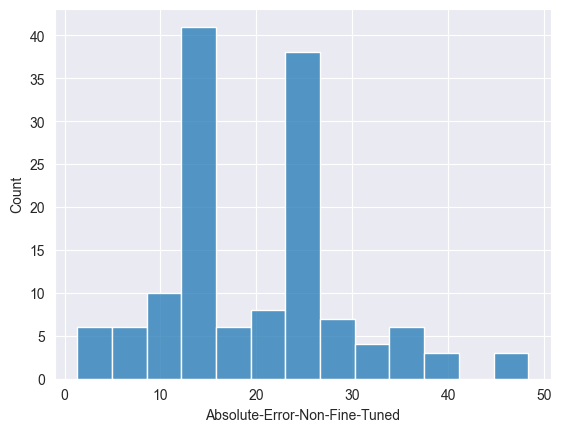

In [45]:
sns.histplot(test['Absolute-Error-Non-Fine-Tuned'])

<Axes: xlabel='Absolute-Error-Fine-Tuned', ylabel='Count'>

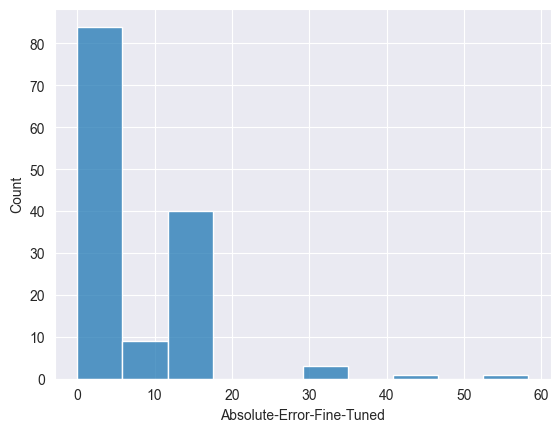

In [46]:
sns.histplot(test['Absolute-Error-Fine-Tuned'])

<Axes: xlabel='Mean-Squared-Error-Fine-Tuned', ylabel='Count'>

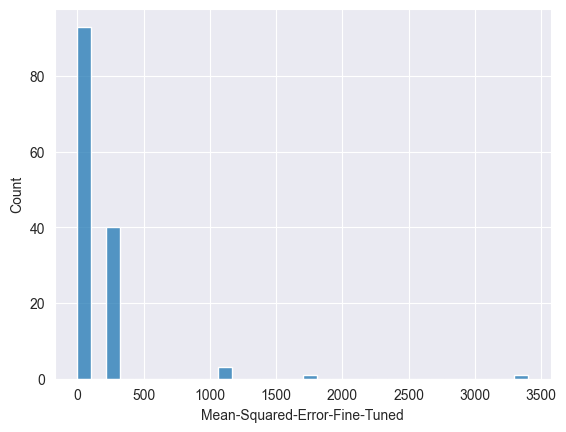

In [47]:
sns.histplot(test['Mean-Squared-Error-Fine-Tuned'])

<Axes: xlabel='Mean-Squared-Error-Non-Fine-Tuned', ylabel='Count'>

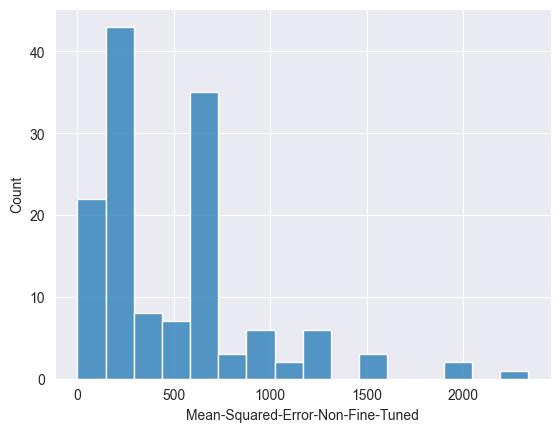

In [48]:
sns.histplot(test['Mean-Squared-Error-Non-Fine-Tuned'])

In [66]:
{ "absolute-error-fine-tuned" : test['Absolute-Error-Fine-Tuned'].apply(abs).mean(), 
"absolute-error-non-fine-tuned" : test['Absolute-Error-Non-Fine-Tuned'].apply(abs).mean(),
  "mean-squared-error-fine-tuned" : test['Mean-Squared-Error-Fine-Tuned'].mean(),
  "mean-squared-error-non-fine-tuned" : test['Mean-Squared-Error-Non-Fine-Tuned'].mean()}

{'absolute-error-fine-tuned': np.float64(6.823961352657004),
 'absolute-error-non-fine-tuned': np.float64(20.17632850241546),
 'mean-squared-error-fine-tuned': np.float64(146.4424333333333),
 'mean-squared-error-non-fine-tuned': np.float64(492.7830112721418)}

In [88]:
test['Absolute-Error-Fine-Tuned'].std(), test['Absolute-Error-Non-Fine-Tuned'].std()

(np.float64(10.030204712645244), np.float64(9.291088094016729))

In [93]:
from scipy import stats

stats.ttest_ind(test['Absolute-Error-Non-Fine-Tuned'], test['Absolute-Error-Fine-Tuned'])

TtestResult(statistic=np.float64(11.472527053290383), pvalue=np.float64(3.832580724903084e-25), df=np.float64(274.0))

In [49]:
router_dataset = pd.read_csv('iq_interview_experiences.csv')
router_dataset.head()

,interview_questions
0,How would you handle a problem customer
1,data types in c programming language?
2,What are oops concepts and collections.
3,1.What is the difference between java and c\n2...
4,puzzels of that 3 button n 3 bulbs


In [50]:
def openai_classify(question, model="gpt-4o-mini"):
    return client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You are given an interview experience, return a json list which splits the experiences such that it is granular enough to be classified by a machine learning model by their domain. Note that the experiences may be valid question or not, nevertheless, assume that you can logically split them. No need to classify their domains, just split them. [\"<experience1>\", \"<experience2>\", ...] Note that the splitting must be verbatim."},
            {"role": "user", "content": question},
        ],
    ).choices[0].message.content

In [51]:
splits = []

for item in router_dataset['interview_questions']:
   result = openai_classify(item)
   try:
         splits.append(json.loads(result))
   except:
       print("Error")

Error
Error


In [52]:
final_split = []
for result in splits:
    for item in result:
        final_split.append(item)

In [53]:
def openai_classify_domain(question, model="gpt-4o-mini"):
    return client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You are given an interview question, return a json list contains their classification. Valid classifications are in the order, "
                                          "1- 'Computer Science'"
                                          "2 - 'Product and Data Science'"
                                          "3 - 'Behavioral'"
                                          "4- 'Vague/Invalid'" + 
             "Example in: 'What is your favorite color?' -> [0, 0, 0, 1]"},
            {"role": "user", "content": question},
        ],
    ).choices[0].message.content

In [54]:
out_list = []
for split in final_split:
    result = openai_classify_domain(split)
    try:
        out = json.loads(result)
        print("Valid")
    except:
        print("Error")
        out_list.append(np.nan)
        continue
    out_list.append(out)

Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Error
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Error
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Valid
Vali

In [55]:
assert len(out_list) == len(final_split)

In [56]:
df_class = pd.DataFrame()
df_class["Computer Science"] = pd.Series()
df_class["Product and Data Science"] = pd.Series()
df_class["Behavioral"] = pd.Series()
df_class["Vague/Invalid"] = pd.Series()
df_class["Experience"] = pd.Series(final_split)
df_class

,Computer Science,Product and Data Science,Behavioral,Vague/Invalid,Experience
0,NaN,NaN,NaN,NaN,How would you handle a problem customer
1,NaN,NaN,NaN,NaN,data types in c programming language?
2,NaN,NaN,NaN,NaN,What are oops concepts?
3,NaN,NaN,NaN,NaN,What are collections?
4,NaN,NaN,NaN,NaN,What is the difference between java and c
...,...,...,...,...,...
867,NaN,NaN,NaN,NaN,easy rest api questions like get/post
868,NaN,NaN,NaN,NaN,some perf considerations
869,NaN,NaN,NaN,NaN,How would you encounter this issue that EAs face?
870,NaN,NaN,NaN,NaN,The normal past experience


In [57]:
len(out_list)

872

In [58]:
out_list[:5]

[[0, 0, 1, 0], [1, 0, 0, 0], [1, 0, 0, 0], [1, 0, 0, 0], [1, 0, 0, 0]]

In [59]:
for i, item in enumerate(out_list):
    if isinstance(item, (float, int)) and np.isnan(item):  # Check if item is a single NaN value
        df_class.loc[i, ["Behavioral", "Computer Science", "Product and Data Science", "Vague/Invalid"]] = np.nan
        continue
    elif (isinstance(item, (list, np.ndarray)) and np.any(np.isnan(item))):  # Check if item is an array containing NaN
        df_class.loc[i, ["Behavioral", "Computer Science", "Product and Data Science", "Vague/Invalid"]] = np.nan
        continue
    if len(item) != 4:
        df_class.loc[i, ["Behavioral", "Computer Science", "Product and Data Science", "Vague/Invalid"]] = np.nan
        continue
    df_class.loc[i, "Behavioral"] = item[2]
    df_class.loc[i, "Computer Science"] = item[0]
    df_class.loc[i, "Product and Data Science"] = item[1]
    df_class.loc[i, "Vague/Invalid"] = item[3]

In [60]:
df_class = df_class.dropna()

In [61]:
df_class

,Computer Science,Product and Data Science,Behavioral,Vague/Invalid,Experience
0,0,0,1,0,How would you handle a problem customer
1,1,0,0,0,data types in c programming language?
2,1,0,0,0,What are oops concepts?
3,1,0,0,0,What are collections?
4,1,0,0,0,What is the difference between java and c
...,...,...,...,...,...
867,1,0,0,0,easy rest api questions like get/post
868,1,0,0,0,some perf considerations
869,0,0,0,1,How would you encounter this issue that EAs face?
870,0,0,0,1,The normal past experience


In [62]:
!pip3 install tf-keras


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [63]:
from sklearn.ensemble import RandomForestClassifier
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
# Load the Sentence-Transformer model
sbert_model = SentenceTransformer("all-distilroberta-v1")
classifier = RandomForestClassifier()
X = df_class['Experience'].astype(str).tolist()
X_embeddings = np.array(sbert_model.encode(X, convert_to_numpy=True))
y_arged = np.argmax(y, axis=1)
train_x, test_x, train_y, test_y = train_test_split(X_embeddings, y_arged, test_size=0.4, random_state=42)
classifier.fit(train_x, train_y)
classifier.score(test_x, test_y)


/Users/rufelleemmanuelpactol/InternshipData/SpecTopExperiments/.venv/lib/python3.9/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
/Users/rufelleemmanuelpactol/InternshipData/SpecTopExperiments/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.1k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

NameError: name 'y' is not defined

In [72]:
!pip3 install imbalanced-learn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [83]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


# Missing DataFrame definition
# Assuming df_class is loaded from somewhere, add this line:
# df_class = pd.read_csv('your_data.csv')  # Uncomment and replace with your data source

# Use SentenceTransformer directly instead of DistilBert + conversion
sbert_model = SentenceTransformer('distilbert-base-nli-mean-tokens')

# Extract textual feature (Experience) and categorical labels
# Check if DataFrame exists first
if 'df_class' in locals() or 'df_class' in globals():
    X = df_class['Experience'].astype(str).tolist()  # Convert to a list of strings
    y = df_class[['Computer Science', 'Product and Data Science', 'Behavioral', 'Vague/Invalid']].values
else:
    raise ValueError("DataFrame 'df_class' is not defined. Please load your data first.")

# Ensure y is in float format
y = y.astype(np.float32)

# Convert text to embeddings using Sentence-Transformers
X_embeddings = np.array(sbert_model.encode(X))

# Normalize embeddings - this can help stabilize training
scaler = StandardScaler()
X_embeddings = scaler.fit_transform(X_embeddings)

# Fix: Convert one-hot encoded y to class indices for SMOTE
y_indices = np.argmax(y, axis=1)

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_embeddings, y_indices, test_size=0.4, random_state=42)
X_resampled, y_indices_resampled = smote.fit_resample(X_train, y_train)

# Convert class indices back to one-hot encoding for neural network training
y_resampled = tf.keras.utils.to_categorical(y_indices_resampled, num_classes=4)
y_test_resampled = tf.keras.utils.to_categorical(y_test, num_classes=4)

# Split into train and test sets



Epoch 1/50
125/125 [==============================] - 1s 3ms/step - loss: 2.4462 - accuracy: 0.4363 - val_loss: 1.9798 - val_accuracy: 0.6847 - lr: 0.0010
Epoch 2/50
125/125 [==============================] - 0s 2ms/step - loss: 2.1681 - accuracy: 0.5296 - val_loss: 1.8223 - val_accuracy: 0.7207 - lr: 0.0010
Epoch 3/50
125/125 [==============================] - 0s 2ms/step - loss: 2.0214 - accuracy: 0.5918 - val_loss: 1.7847 - val_accuracy: 0.7117 - lr: 0.0010
Epoch 4/50
125/125 [==============================] - 0s 2ms/step - loss: 1.9797 - accuracy: 0.6028 - val_loss: 1.7238 - val_accuracy: 0.7477 - lr: 0.0010
Epoch 5/50
125/125 [==============================] - 0s 2ms/step - loss: 1.9167 - accuracy: 0.6449 - val_loss: 1.6539 - val_accuracy: 0.7928 - lr: 0.0010
Epoch 6/50
125/125 [==============================] - 0s 2ms/step - loss: 1.8619 - accuracy: 0.6770 - val_loss: 1.6317 - val_accuracy: 0.7928 - lr: 0.0010
Epoch 7/50
125/125 [==============================] - 0s 2ms/step - lo

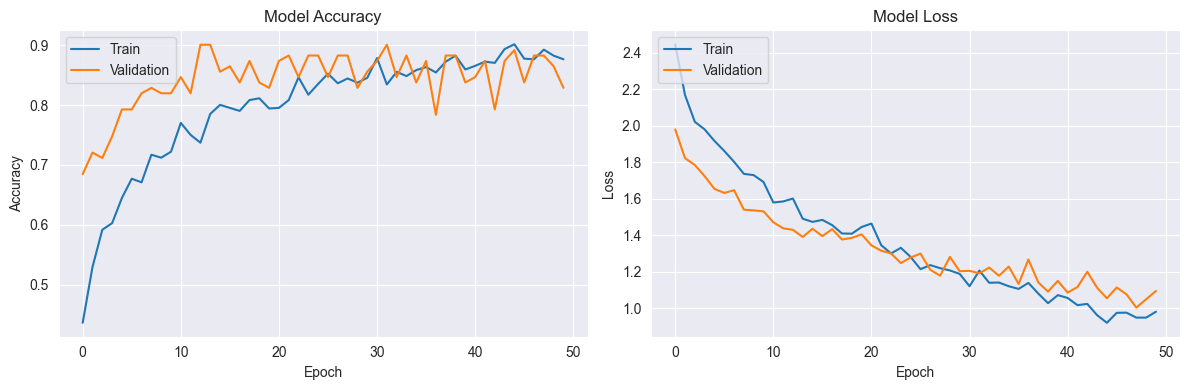

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_41 (Dense)            (None, 512)               393728    
                                                                 
 batch_normalization_32 (Ba  (None, 512)               2048      
 tchNormalization)                                               
                                                                 
 dropout_32 (Dropout)        (None, 512)               0         
                                                                 
 dense_42 (Dense)            (None, 128)               65664     
                                                                 
 batch_normalization_33 (Ba  (None, 128)               512       
 tchNormalization)                                               
                                                                 
 dropout_33 (Dropout)        (None, 128)              

In [84]:
# train_x, test_x, train_y, test_y = train_test_split(X_resampled, y_resampled, test_size=0.15, random_state=42)
# Define the model with more regularization
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_embeddings.shape[1],)),
    # Reduced model complexity
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),  # Add batch normalization
    tf.keras.layers.Dropout(0.3),  # Increased dropout
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),  # Add batch normalization
    tf.keras.layers.Dropout(0.3),  # Increased dropout

    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(4, activation='softmax')  # Output layer
])

# Compile the model with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Reduced learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Learning rate scheduler to gradually reduce learning rate
def lr_scheduler(epoch, lr):
    if epoch > 0 and epoch % 10 == 0:
        return lr * 0.9
    return lr

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# Early stopping callback with increased patience
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,  # Increased patience
    restore_best_weights=True
)

# Train the model with more regularization
history = model.fit(
    train_x,
    train_y,
    epochs=50,  # Reduced epochs to avoid overfitting
    batch_size=8,  # Adjusted batch size for better gradient estimates
    validation_split=0.1,  # Use part of training data for validation during training
    callbacks=[early_stopping, lr_callback],
    shuffle=True  # Ensure data is shuffled each epoch
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test_resampled)
print(f"Test Accuracy: {test_acc:.4f}")

# Optional: Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Display a summary of the model architecture
model.summary()

In [ ]:
import tensorflow as tf
